# **Exercise 1**

# Question 1 and Question 2 need not to be submitted

# Initial information about data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,7.137490
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-1.873581
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,1.492563
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,-9.290940
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,-1.088668


In [2]:
df.shape

(500, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      500 non-null    float64
 1   x2      500 non-null    float64
 2   x3      500 non-null    float64
 3   x4      500 non-null    float64
 4   x5      500 non-null    float64
 5   x6      500 non-null    float64
 6   x7      500 non-null    float64
 7   x8      500 non-null    float64
 8   x9      500 non-null    float64
 9   x10     500 non-null    float64
 10  y       500 non-null    float64
dtypes: float64(11)
memory usage: 43.1 KB


In [4]:
df.describe()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.003143,0.020149,0.005058,-0.032688,-0.006497,-0.000549,-0.054563,0.004027,0.045750,0.072188,-0.201277
std,0.956440,1.061453,1.008065,0.980525,1.017848,1.041198,0.995664,1.003579,0.938045,0.958350,6.168417
min,-2.703232,-2.940389,-3.241267,-2.839079,-3.019512,-3.170426,-2.704392,-2.991136,-3.007632,-3.176704,-17.762082
25%,-0.607822,-0.678549,-0.681772,-0.771787,-0.660905,-0.695476,-0.770440,-0.708796,-0.532287,-0.508140,-4.404808
50%,0.040920,-0.025355,0.023546,0.022736,-0.045020,0.019309,-0.043463,0.021525,0.096510,0.024099,-0.126899
75%,0.639625,0.749506,0.641757,0.673563,0.690822,0.666112,0.598299,0.643416,0.680031,0.687920,4.233960
max,3.076860,2.985259,3.152057,2.601683,2.755218,3.926238,3.243093,3.137749,3.078881,3.852731,19.583698


In [5]:
A = df[[f"x{i}" for i in range(1, 11)]].values   # (500, 10)
b = df["y"].values                               # (500,)

m,n = A.shape

print(f"Number of samples: {m}")
print(f"Number of features: {n}")

Number of samples: 500
Number of features: 10


In [6]:
def f(x):
    r = A@x-b
    return 0.5*np.dot(r,r)

def grad_f(x):
    return A.T @ (A@x-b)

def hess_f(x):
    return A.T @ A

In [7]:
def backtracking(x,p,grad, alpha0=0.99, rho=0.5, gamma=0.5):
    alpha = alpha0
    fx = f(x)
    while f(x+alpha*p) > fx + gamma*alpha*grad@p:
        alpha *= rho
    return alpha

# Question 3

In [8]:
def newton_method(x0, tol=1e-4, max_iter=1000):
    x = x0.copy()
    xs = [x.copy()]
    fs = [f(x)]

    H = hess_f(x)  # Hessian is constant for quadratic functions, so we compute it once

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        p = np.linalg.solve(H,-g)
        alpha = backtracking(x,p,g)
        x += alpha*p
        xs.append(x.copy())
        fs.append(f(x))

    return np.array(xs), np.array(fs)

In [9]:
x0 = np.zeros(n)
xs_newton, fs_newton = newton_method(x0)
x_star_newton = xs_newton[-1]
x_bar = np.linalg.solve(A.T @ A, A.T @ b)

In [10]:
table_newton = pd.DataFrame({
    "Newton x*": x_star_newton,
    "Closed-form x̄": x_bar,
    "|Difference|": np.abs(x_star_newton - x_bar)
})

table_newton.loc["||x* - x̄||₂"] = ["", "", np.linalg.norm(x_star_newton - x_bar)]
table_newton

,Newton x*,Closed-form x̄,|Difference|
0,1.48123,1.48123,1.481230e-08
1,-1.988386,-1.988386,1.988386e-08
2,0.513133,0.513133,5.131329e-09
3,3.007375,3.007375,3.007375e-08
4,-1.177559,-1.177559,1.177559e-08
5,2.499035,2.499035,2.499035e-08
6,-0.703399,-0.703399,7.033993e-09
7,1.018677,1.018677,1.018677e-08
8,-3.446069,-3.446069,3.446070e-08
9,0.781972,0.781972,7.819725e-09


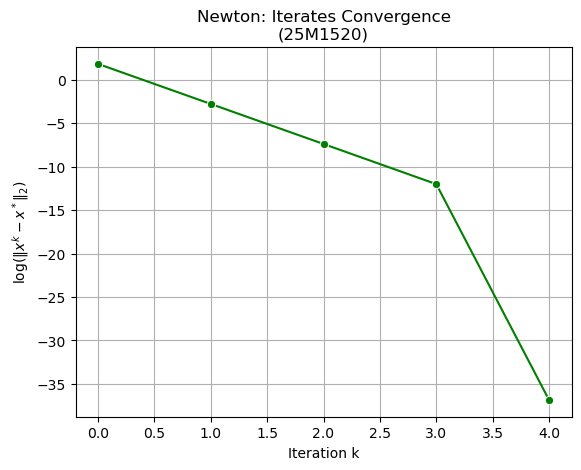

In [11]:
errors_newton = np.linalg.norm(xs_newton-x_star_newton, axis=1)

df_plot = pd.DataFrame({
    "Iteration": np.arange(len(errors_newton)),
    "log_error": np.log(errors_newton+1e-16)
})

sns.lineplot(data=df_plot, x="Iteration", y="log_error", marker="o", color='g')
plt.xlabel("Iteration k")
plt.ylabel(r"log($\|x^k - x^*\|_2$)")
plt.title("Newton: Iterates Convergence\n(25M1520)")
plt.grid(True)
plt.show()

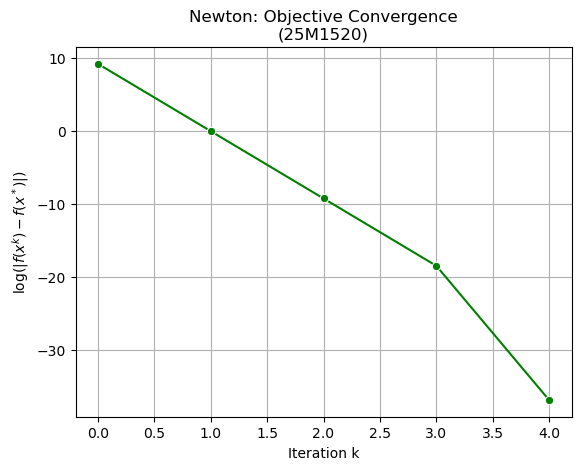

In [12]:
obj_error_newton = np.abs(fs_newton-fs_newton[-1])

df_plot = pd.DataFrame({
    "Iteration": np.arange(len(fs_newton)),
    "log_obj_error": np.log(obj_error_newton+1e-16)
})

sns.lineplot(data=df_plot, x="Iteration", y="log_obj_error", marker="o", color='g')
plt.xlabel("Iteration k")
plt.ylabel(r"log($|f(x^k) - f(x^*)|$)")
plt.title("Newton: Objective Convergence\n(25M1520)")
plt.grid(True)
plt.show()

#### Comment on Newton's Convergence :
* Iterates: Quadratic convergence (reaches solution in one step for a quadratic objective)
* Objective: Quadratic convergence
* Performance: Optimal / fastest possible for this problem 

# Question 4

In [13]:
def bfgs_method(x0, tol=1e-4, max_iter=1000):
    x = x0.copy()
    H = np.eye(len(x))
    xs = [x.copy()]
    fs = [f(x)]

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        p = -H@g
        alpha = backtracking(x,p,g)
        s = alpha*p
        x_new = x+s
        y = grad_f(x_new) - g
        rho = 1.0 / (y@s)
        I = np.eye(len(x))
        H = (I - rho*np.outer(s,y)) @ H @ (I - rho*np.outer(y,s)) + rho*np.outer(s,s)
        x = x_new
        xs.append(x.copy())
        fs.append(f(x))

    return np.array(xs), np.array(fs)

In [14]:
xs_bfgs, fs_bfgs = bfgs_method(x0)
x_star_bfgs = xs_bfgs[-1]

In [15]:
table_bfgs = pd.DataFrame({
    "BFGS x*": x_star_bfgs,
    "Closed-form x̄": x_bar,
    "|Difference|": np.abs(x_star_bfgs - x_bar)
})

table_bfgs.loc["||x* - x̄||₂"] = ["", "", np.linalg.norm(x_star_bfgs - x_bar)]
table_bfgs

,BFGS x*,Closed-form x̄,|Difference|
0,1.48123,1.48123,2.636427e-10
1,-1.988386,-1.988386,2.465943e-09
2,0.513133,0.513133,1.685039e-09
3,3.007375,3.007375,2.943263e-09
4,-1.177559,-1.177559,7.822196e-10
5,2.499035,2.499035,3.951357e-09
6,-0.703399,-0.703399,2.460390e-09
7,1.018677,1.018677,3.014605e-09
8,-3.446069,-3.446069,2.069453e-09
9,0.781972,0.781972,1.248941e-09


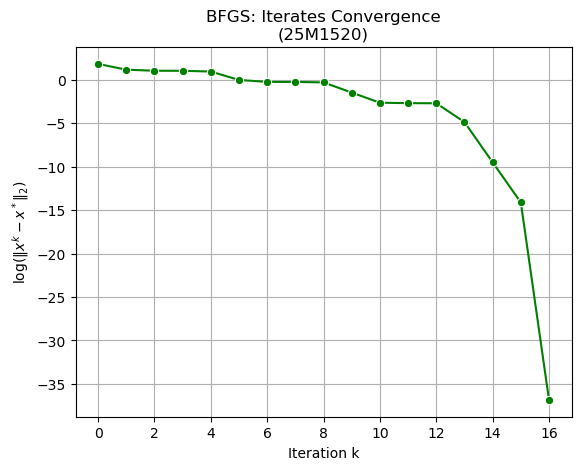

In [16]:
errors_bfgs = np.linalg.norm(xs_bfgs-x_star_bfgs, axis=1)

df_plot = pd.DataFrame({
    "Iteration": np.arange(len(errors_bfgs)),
    "log_error": np.log(errors_bfgs+1e-16)
})

sns.lineplot(data=df_plot, x="Iteration", y="log_error", marker="o", color='g')
plt.xlabel("Iteration k")
plt.ylabel(r"log($\|x^k - x^*\|_2$)")
plt.title("BFGS: Iterates Convergence\n(25M1520)")
plt.grid(True)
plt.show()

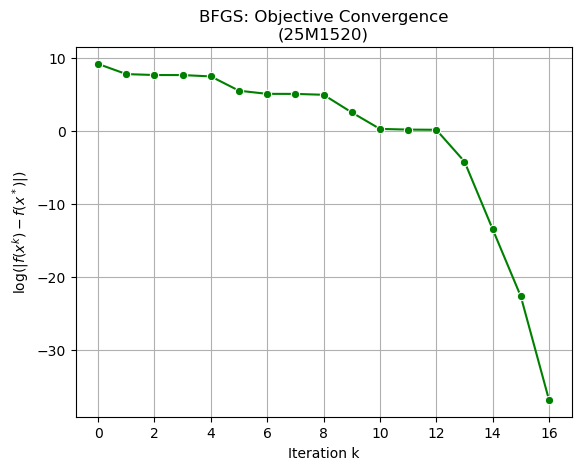

In [17]:
obj_error_bfgs = np.abs(fs_bfgs - fs_bfgs[-1])

df_plot = pd.DataFrame({
    "Iteration": np.arange(len(fs_bfgs)),
    "log_obj_error": np.log(obj_error_bfgs+1e-16)
})

sns.lineplot(data=df_plot, x="Iteration", y="log_obj_error", marker="o", color='g')
plt.xlabel("Iteration k")
plt.ylabel(r"log($|f(x^k) - f(x^*)|$)")
plt.title("BFGS: Objective Convergence\n(25M1520)")
plt.grid(True)
plt.show()


#### Comment on BFGS Convergence :
* Iterates: Superlinear but Subquadratic
* Objective: Superlinear decrease
* Performance: More iterations than Newton, but avoids Hessian computation

# Question 5

In [18]:
import time

# Initial point
x0 = np.zeros(n)

# Time Newton's method
start = time.time()
xs_newton, fs_newton = newton_method(x0)
time_newton = time.time() - start

# Time BFGS method
start = time.time()
xs_bfgs, fs_bfgs = bfgs_method(x0)
time_bfgs = time.time() - start

print("Newton time (microseconds):", time_newton*1e6)
print("BFGS time (microseconds):", time_bfgs*1e6)

comparison = pd.DataFrame({
    "Method": ["Newton", "BFGS"],
    "Iterations": [len(xs_newton)-1, len(xs_bfgs)-1],
    "Final objective value": [fs_newton[-1], fs_bfgs[-1]],
    "Time (μs)": [time_newton*1e6, time_bfgs*1e6]
})

comparison

Newton time (microseconds): 751.2569427490234
BFGS time (microseconds): 3141.8800354003906


,Method,Iterations,Final objective value,Time (μs)
0,Newton,4,57.561553,751.256943
1,BFGS,16,57.561553,3141.880035


#### Newton’s method
* Converges in one iteration for this quadratic problem
* Fastest overall, but requires Hessian (or linear solve)
#### BFGS
* Requires more iterations
* Slightly slower, but avoids Hessian computation
* More suitable for large-scale or non-quadratic problems

For this least-squares problem, Newton’s method outperforms BFGS in both iterations and total runtime due to the quadratic nature of the objective. However, BFGS provides a robust alternative when Hessian computation is expensive or impractical.

# **Exercise 2**

# Question 1 and Question 2 need not to be submitted

# Initial definitions of Function, Gradient, Hessian

In [19]:
def f_lambda(x,A,b,lam):
    return 0.5*lam*np.dot(x,x) + 0.5*np.linalg.norm(A@x-b)**2

def grad_f_lambda(x,A,b,lam):
    return lam*x + A.T@(A@x-b)

def hessian_f_lambda(A,lam):
    n = A.shape[1]
    return lam*np.eye(n) + A.T@A

In [20]:
def closed_form_solution(A,b,lam):
    n = A.shape[1]
    return np.linalg.solve(A.T@A + lam*np.eye(n), A.T@b)

# Question 3

In [21]:
def backtracking_lambda(x,A,b,lam,p, alpha0=0.99, rho=0.5, gamma=0.5):
    alpha = alpha0
    fx = f_lambda(x,A,b,lam)
    grad = grad_f_lambda(x,A,b,lam)
    while f_lambda(x+alpha*p, A,b,lam) > fx + gamma*alpha*grad@p:
        alpha *= rho
    return alpha

def newton_method_path(x0,A,b,lam, tol=1e-5, max_iter=1000):
    x = x0.copy()
    H = hessian_f_lambda(A,lam)

    path = [x.copy()]
    fvals = [f_lambda(x,A,b,lam)]

    for k in range(max_iter):
        grad = grad_f_lambda(x,A,b,lam)
        if np.linalg.norm(grad) < tol:
            break

        p = -np.linalg.solve(H,grad)
        alpha = backtracking_lambda(x, A, b, lam, p)
        x += alpha*p

        path.append(x.copy())
        fvals.append(f_lambda(x,A,b,lam))

    return x, np.array(path), np.array(fvals), k

def bfgs_method_path(x0,A,b,lam, tol=1e-5, max_iter=1000):
    x = x0.copy()
    n = len(x)
    Hk = np.eye(n)

    path = [x.copy()]
    fvals = [f_lambda(x,A,b,lam)]

    for k in range(max_iter):
        grad = grad_f_lambda(x,A,b,lam)
        if np.linalg.norm(grad) < tol:
            break
        p = -Hk @ grad
        alpha = backtracking_lambda(x,A,b,lam,p)
        x_new = x + alpha*p
        grad_new = grad_f_lambda(x_new,A,b,lam)
        s = x_new - x
        yk = grad_new - grad
        rho = 1.0 / (yk@s)
        I = np.eye(n)
        Hk = (I - rho*np.outer(s,yk)) @ Hk @ (I - rho*np.outer(yk,s)) + rho*np.outer(s,s)
        x = x_new
        path.append(x.copy())
        fvals.append(f_lambda(x,A,b,lam))

    return x, np.array(path), np.array(fvals), k

In [22]:
lambdas = [1e-3, 1e-2, 1e-1, 1]
results = []

for lam in lambdas:
    x_star = closed_form_solution(A,b,lam)
    # Newton
    start = time.time()
    x_newton, path_n, fvals_n, it_n = newton_method_path(x0, A, b, lam)
    t_n = time.time() - start
    # BFGS
    start = time.time()
    x_bfgs, path_b, fvals_b, it_b = bfgs_method_path(x0, A, b, lam)
    t_b = time.time() - start

    results.append([lam,it_n,np.linalg.norm(x_newton-x_star),t_n, it_b,np.linalg.norm(x_bfgs-x_star),t_b])

columns = ["Lambda","Newton Iter","Newton Error","Newton Time","BFGS Iter","BFGS Error","BFGS Time"]

results_df = pd.DataFrame(results, columns=columns)
results_df

,Lambda,Newton Iter,Newton Error,Newton Time,BFGS Iter,BFGS Error,BFGS Time
0,0.001,5,6.091518e-10,0.000490,16,7.406487e-09,0.005583
1,0.010,5,6.091393e-10,0.000443,16,7.403175e-09,0.004351
2,0.100,5,6.090278e-10,0.000435,16,7.370163e-09,0.003547
3,1.000,6,1.550329e-08,0.000537,16,7.050063e-09,0.002346


# Question 4

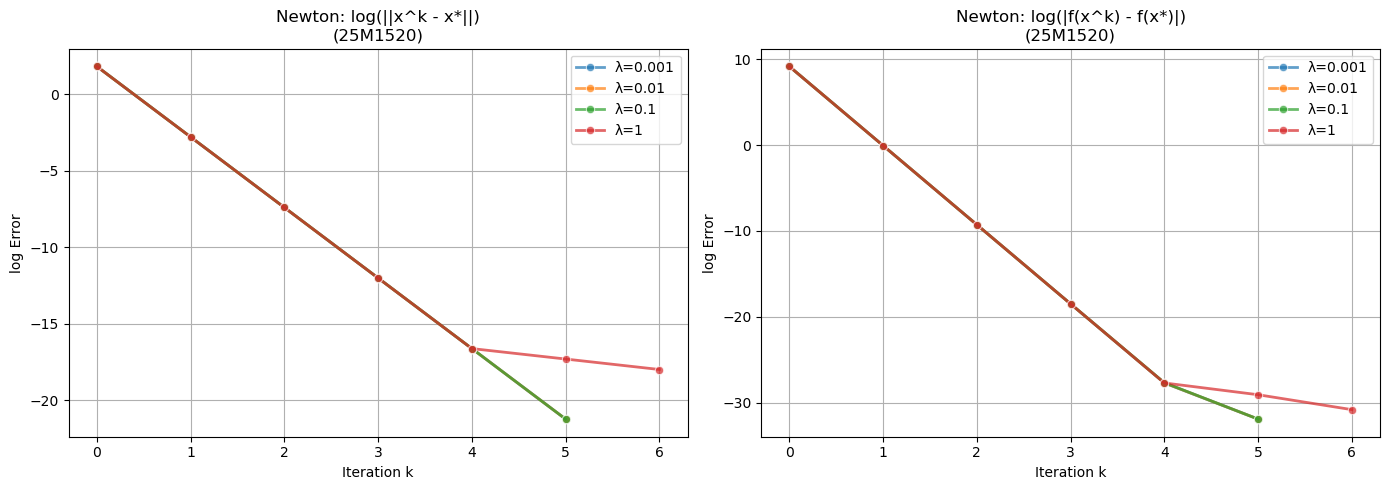

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette("tab10", len(lambdas))  # strong distinct colors

for i, lam in enumerate(lambdas):
    x_star = closed_form_solution(A, b, lam)
    f_star = f_lambda(x_star, A, b, lam)

    _, path, fvals, _ = newton_method_path(x0, A, b, lam)

    iter_err = np.maximum([np.linalg.norm(x - x_star) for x in path], 1e-15)
    func_err = np.maximum(np.abs(fvals - f_star), 1e-15)

    for ax, err in zip(axes, [iter_err, func_err]):
        sns.lineplot(x=range(len(err)),
                     y=np.log(err),
                     ax=ax,
                     marker="o",
                     label=f"λ={lam}",
                     color=palette[i],
                     alpha=0.7, linewidth=2)

titles = ["Newton: log(||x^k - x*||)",
          "Newton: log(|f(x^k) - f(x*)|)"]

for ax, title in zip(axes, titles):
    ax.set_title(title + "\n(25M1520)")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel("log Error")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Question 5

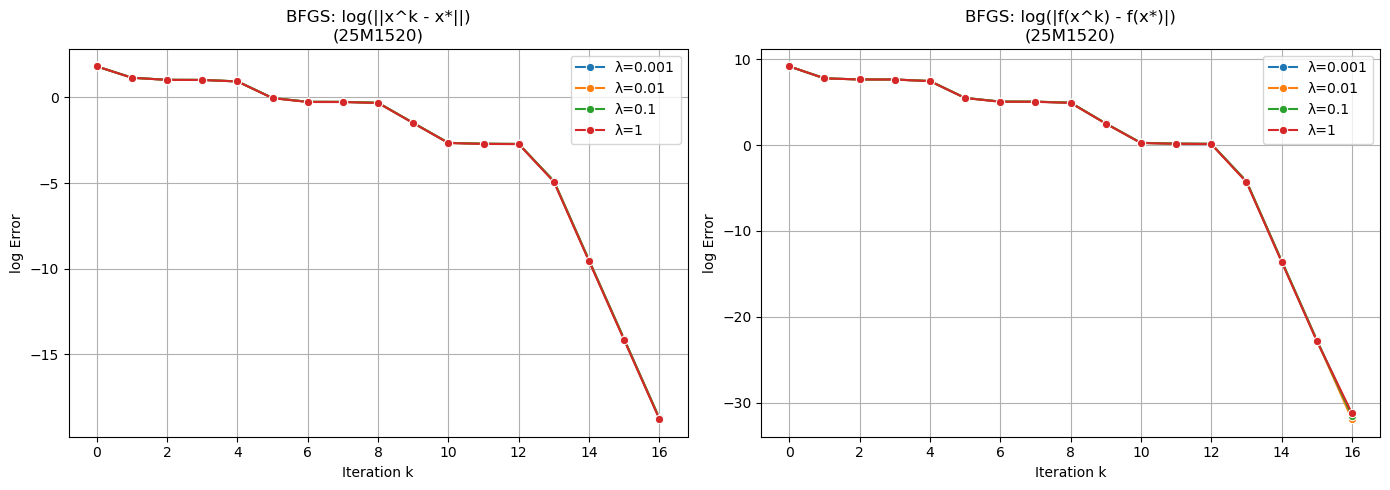

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lam in lambdas:
    x_star = closed_form_solution(A, b, lam)
    f_star = f_lambda(x_star, A, b, lam)

    _, path, fvals, _ = bfgs_method_path(x0, A, b, lam)

    iter_err = np.maximum([np.linalg.norm(x - x_star) for x in path], 1e-15)
    func_err = np.maximum(np.abs(fvals - f_star), 1e-15)

    for ax, err in zip(axes, [iter_err, func_err]):
        sns.lineplot(x=range(len(err)),
                     y=np.log(err),
                     ax=ax,
                     marker="o",
                     label=f"λ={lam}")

titles = ["BFGS: log(||x^k - x*||)",
          "BFGS: log(|f(x^k) - f(x*)|)"]

for ax, title in zip(axes, titles):
    ax.set_title(title + "\n(25M1520)")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel("log Error")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Question 6

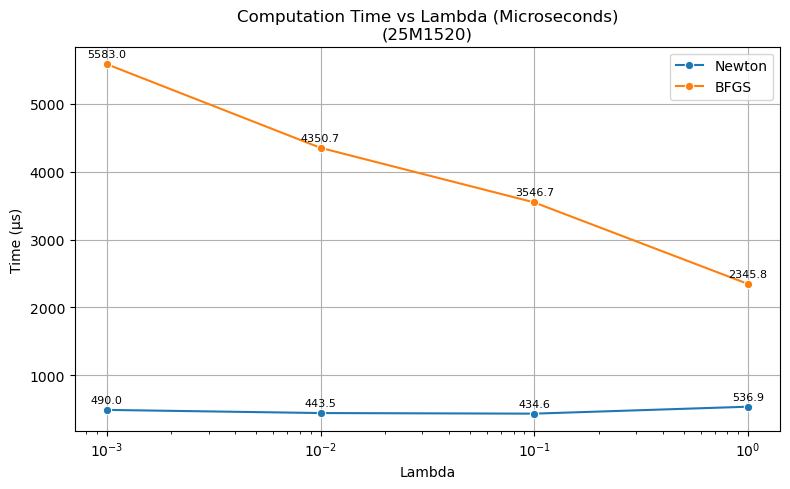

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

for col in ["Newton Time", "BFGS Time"]:
    
    times_micro = results_df[col] * 1e6
    
    sns.lineplot(x=results_df["Lambda"],
                 y=times_micro,
                 marker="o",
                 ax=ax,
                 label=col.replace(" Time", ""))
    
    # Annotate each point
    for x, y in zip(results_df["Lambda"], times_micro):
        ax.annotate(f"{y:.1f}",
                    (x, y),
                    textcoords="offset points",
                    xytext=(0,5),
                    ha='center',
                    fontsize=8)

ax.set_title("Computation Time vs Lambda (Microseconds)\n(25M1520)")
ax.set_xlabel("Lambda")
ax.set_ylabel("Time (μs)")
ax.set_xscale("log")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

#### Comment 
* Newton’s method requires significantly fewer iterations compared to BFGS due to its quadratic convergence.
* However, each Newton iteration involves solving a linear system, making it computationally heavier per step.
* BFGS requires more iterations but each step is cheaper since it avoids computing the exact Hessian.
* As λ increases, the problem becomes better conditioned, leading to faster convergence for both methods.
* For this low-dimensional problem (n = 10), Newton is generally faster overall in terms of total computation time.

Hence, Newton performs better here, while BFGS is preferable in higher-dimensional problems where computing the Hessian is expensive.